# 03 - Time-Series ADR Forecasting (ARIMA)

**Goal**: Forecast Average Daily Rate (ADR) over time using ARIMA models.

**Approach**:
- Aggregate ADR by date (daily time series)
- Time-based train/test split
- Build simple baseline forecasts (naive, mean, moving average)
- Analyze stationarity (ADF test, ACF/PACF plots)
- Build and tune ARIMA model
- Compare all methods using RMSE, MAE, MAPE
- Visualize forecasts and save best model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

np.random.seed(42)

## 1. Load and Prepare Time Series Data

In [2]:
# Load dataset
df = pd.read_csv('../data/hotel_bookings.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows ? {df.shape[1]} columns")

# Create arrival_date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str).str.zfill(2),
    format='%Y-%B-%d',
    errors='coerce'
)

n_nat = df['arrival_date'].isna().sum()
if n_nat:
    print(f'WARNING: arrival_date parse failures: {n_nat:,}')

print(f"Date range: {df['arrival_date'].min()} to {df['arrival_date'].max()}")


Dataset loaded: 119,390 rows ? 32 columns
Date range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00


In [3]:
# Filter valid ADR values
df_clean = df[df['adr'] > 0].copy()
print(f"After filtering negative/zero ADR: {len(df_clean):,} rows")

# Aggregate ADR by date (mean daily ADR)
ts_daily = df_clean.groupby('arrival_date')['adr'].agg(['mean', 'median', 'count']).reset_index()
ts_daily.columns = ['date', 'adr_mean', 'adr_median', 'booking_count']
ts_daily = ts_daily.sort_values('date').reset_index(drop=True)
ts_daily = ts_daily.set_index('date')

# Ensure daily frequency and track missing days (avoid leakage)
ts_daily = ts_daily.asfreq('D')
missing_days = int(ts_daily['adr_mean'].isna().sum())
if missing_days:
    print(f"Missing days (no bookings): {missing_days:,}")

# Fill booking_count with 0 for missing days; keep ADR as NaN
ts_daily['booking_count'] = ts_daily['booking_count'].fillna(0)

print()
print(f"Time series shape: {ts_daily.shape}")
print(f"Date range: {ts_daily.index.min()} to {ts_daily.index.max()}")
print(f"Total days: {len(ts_daily)}")
print()
print("Daily ADR statistics (non-missing days):")
print(ts_daily['adr_mean'].dropna().describe())


After filtering negative/zero ADR: 117,430 rows

Time series shape: (793, 3)
Date range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00
Total days: 793

Daily ADR statistics (non-missing days):
count    793.000000
mean      99.913787
std       28.828858
min       47.112264
25%       77.235000
50%       94.639281
75%      119.666583
max      184.124631
Name: adr_mean, dtype: float64


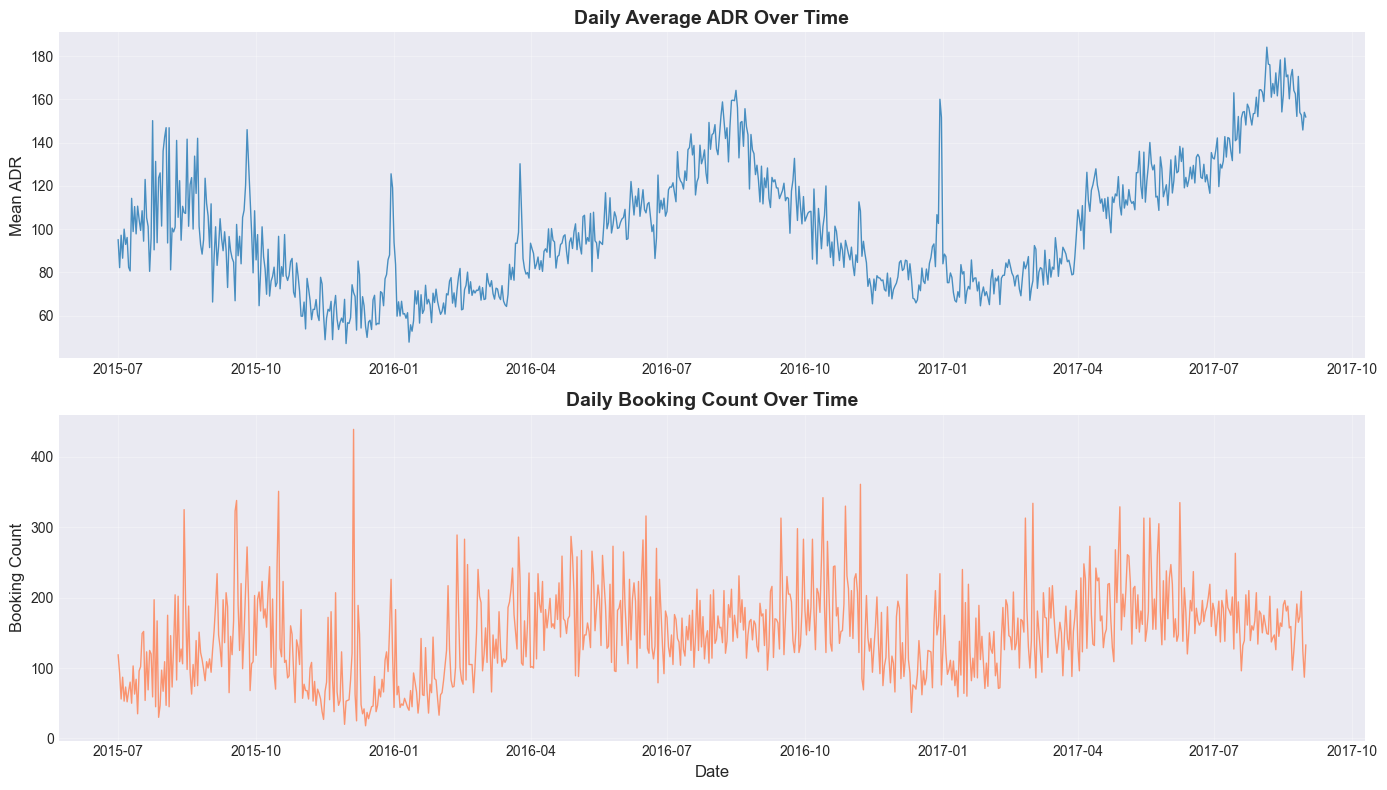

In [4]:
# Visualize time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ADR over time
axes[0].plot(ts_daily.index, ts_daily['adr_mean'], linewidth=1, alpha=0.8)
axes[0].set_ylabel('Mean ADR', fontsize=12)
axes[0].set_title('Daily Average ADR Over Time', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Booking count over time
axes[1].plot(ts_daily.index, ts_daily['booking_count'], linewidth=1, alpha=0.8, color='coral')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Booking Count', fontsize=12)
axes[1].set_title('Daily Booking Count Over Time', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Time-Based Train/Test Split

In [5]:
# Use 80/20 split
split_idx = int(len(ts_daily) * 0.8)
split_date = ts_daily.index[split_idx]

train_ts = ts_daily.iloc[:split_idx].copy()
test_ts = ts_daily.iloc[split_idx:].copy()

# Interpolate training series only (avoid future leakage)
train_ts['adr_mean'] = train_ts['adr_mean'].interpolate(method='time').ffill().bfill()
train_ts['adr_median'] = train_ts['adr_median'].interpolate(method='time').ffill().bfill()

# Keep original missingness mask for evaluation
_test_missing_mask = test_ts['adr_mean'].isna()
valid_idx = test_ts.index[~_test_missing_mask]

# For plotting, create a filled copy of test
_test_ts_plot = test_ts.copy()
_test_ts_plot['adr_mean'] = _test_ts_plot['adr_mean'].interpolate(method='time').ffill().bfill()
_test_ts_plot['adr_median'] = _test_ts_plot['adr_median'].interpolate(method='time').ffill().bfill()

test_ts_plot = _test_ts_plot

print(f"Split date: {split_date}")
print()
print(f"Train set: {len(train_ts)} days ({len(train_ts)/len(ts_daily)*100:.1f}%)")
print(f"  Date range: {train_ts.index.min()} to {train_ts.index.max()}")
print(f"  ADR mean: {train_ts['adr_mean'].mean():.2f}, std: {train_ts['adr_mean'].std():.2f}")

print()
print(f"Test set: {len(test_ts)} days ({len(test_ts)/len(ts_daily)*100:.1f}%)")
print(f"  Date range: {test_ts.index.min()} to {test_ts.index.max()}")
print(f"  ADR mean (non-missing): {test_ts['adr_mean'].dropna().mean():.2f}, std: {test_ts['adr_mean'].dropna().std():.2f}")


Split date: 2017-03-26 00:00:00

Train set: 634 days (79.9%)
  Date range: 2015-07-01 00:00:00 to 2017-03-25 00:00:00
  ADR mean: 91.80, std: 24.16

Test set: 159 days (20.1%)
  Date range: 2017-03-26 00:00:00 to 2017-08-31 00:00:00
  ADR mean (non-missing): 132.25, std: 22.60


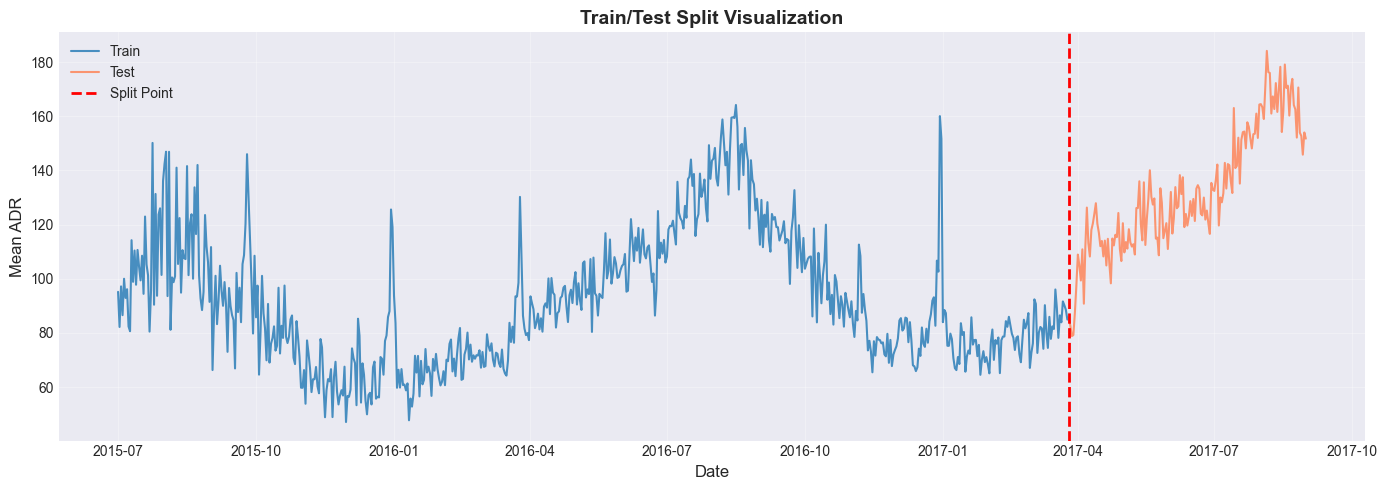

In [6]:
# Visualize train/test split
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_ts.index, train_ts['adr_mean'], label='Train', linewidth=1.5, alpha=0.8)
ax.plot(test_ts_plot.index, test_ts_plot['adr_mean'], label='Test', linewidth=1.5, alpha=0.8, color='coral')
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=2, label='Split Point')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean ADR', fontsize=12)
ax.set_title('Train/Test Split Visualization', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Baseline Forecasts

In [7]:
# Baseline 1: Naive forecast (last observed value)
naive_forecast = np.full(len(test_ts), train_ts['adr_mean'].iloc[-1])

# Baseline 2: Mean forecast (historical mean)
mean_forecast = np.full(len(test_ts), train_ts['adr_mean'].mean())

# Baseline 3: Moving average (last 7 days)
ma_window = 7
ma_forecast = np.full(len(test_ts), train_ts['adr_mean'].iloc[-ma_window:].mean())

# Baseline 4: Seasonal naive (same day last week) - FIXED to avoid data leakage
# Uses rolling forecast: for each step, use the value from 7 days ago (from train or prior forecasts)
seasonal_naive_forecast = []
combined_series = train_ts['adr_mean'].tolist()  # Start with training data

for i in range(len(test_ts)):
    # Use value from 7 days ago (from the combined historical + forecast series)
    week_ago_value = combined_series[-(7)]
    seasonal_naive_forecast.append(week_ago_value)
    combined_series.append(week_ago_value)  # Add forecast to rolling window

seasonal_naive_forecast = np.array(seasonal_naive_forecast)

print("✓ Baseline forecasts created")

✓ Baseline forecasts created


In [8]:
# Evaluate baseline forecasts
# Align forecasts to valid test dates only

def align_forecast(forecast):
    forecast_series = pd.Series(forecast, index=test_ts.index)
    return forecast_series.loc[valid_idx].values


def evaluate_forecast(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    }

# Use only non-missing actuals for evaluation
y_true = test_ts.loc[valid_idx, 'adr_mean'].values

baseline_results = [
    evaluate_forecast(y_true, align_forecast(naive_forecast), 'Naive (Last Value)'),
    evaluate_forecast(y_true, align_forecast(mean_forecast), 'Mean'),
    evaluate_forecast(y_true, align_forecast(ma_forecast), f'Moving Average ({ma_window} days)'),
    evaluate_forecast(y_true, align_forecast(seasonal_naive_forecast), 'Seasonal Naive (7-day)')
]

baseline_df = pd.DataFrame(baseline_results)

print()
print("="*70)
print("BASELINE FORECAST RESULTS")
print("="*70)
print(baseline_df.to_string(index=False))
print("="*70)



BASELINE FORECAST RESULTS
                  Model      RMSE       MAE  MAPE (%)
     Naive (Last Value) 52.402143 47.489438 34.050769
                   Mean 46.300672 41.031746 29.195598
Moving Average (7 days) 51.202107 46.214845 33.084389
 Seasonal Naive (7-day) 51.269117 46.299607 33.220276


## 4. Time Series Analysis

In [9]:
# Augmented Dickey-Fuller test for stationarity
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print(f"  ✓ Series is stationary (reject H0)")
    else:
        print(f"  ⚠ Series is non-stationary (fail to reject H0)")
    print()

adf_test(train_ts['adr_mean'], 'Original ADR Series')

ADF Test for Original ADR Series:
  ADF Statistic: -1.3361
  p-value: 0.6125
  Critical Values:
    1%: -3.441
    5%: -2.866
    10%: -2.569
  ⚠ Series is non-stationary (fail to reject H0)



In [10]:
# Check differenced series
train_diff = train_ts['adr_mean'].diff().dropna()
adf_test(train_diff, 'First Differenced ADR Series')

ADF Test for First Differenced ADR Series:
  ADF Statistic: -7.3915
  p-value: 0.0000
  Critical Values:
    1%: -3.441
    5%: -2.866
    10%: -2.569
  ✓ Series is stationary (reject H0)



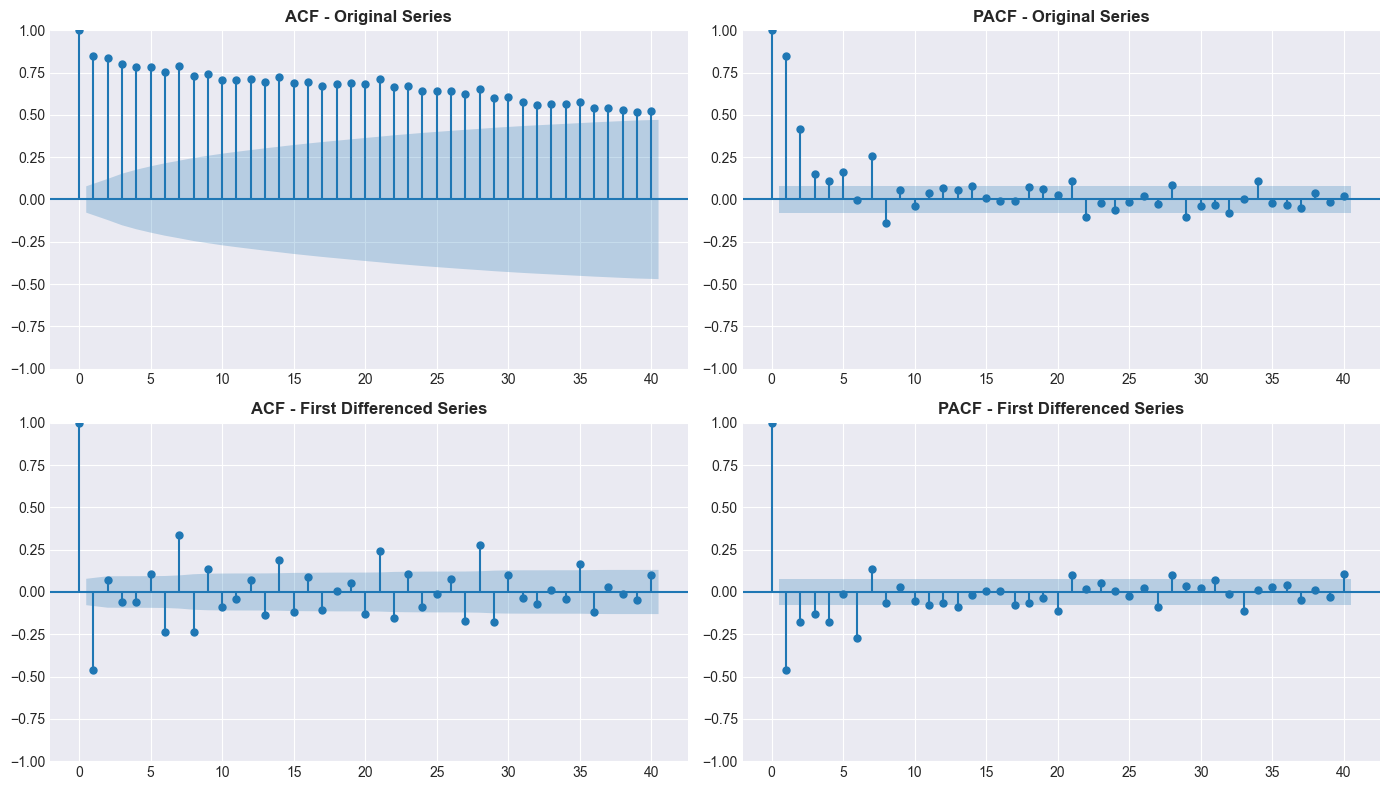

In [11]:
# ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original series
plot_acf(train_ts['adr_mean'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Original Series', fontsize=12, fontweight='bold')

plot_pacf(train_ts['adr_mean'], lags=40, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF - Original Series', fontsize=12, fontweight='bold')

# Differenced series
plot_acf(train_diff, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF - First Differenced Series', fontsize=12, fontweight='bold')

plot_pacf(train_diff, lags=40, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF - First Differenced Series', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. ARIMA Model Selection and Training

In [12]:
# Try different ARIMA configurations
print("Testing multiple ARIMA configurations...")
print()

arima_configs = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
    (3, 1, 1),
    (1, 1, 3),
    (3, 1, 3),
    (5, 1, 0),
    (0, 1, 5),
    (7, 1, 0),
]

arima_results = []

for order in arima_configs:
    try:
        # Fit model
        model = ARIMA(train_ts['adr_mean'], order=order)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            model_fit = model.fit()

        # Improved convergence check
        mle_retvals = getattr(model_fit, 'mle_retvals', None)
        if mle_retvals is not None and not mle_retvals.get('converged', False):
            print(f"ARIMA{order}: Did not converge - skipped")
            continue

        # Make predictions
        forecast = model_fit.forecast(steps=len(test_ts))
        forecast_eval = align_forecast(forecast)

        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_true, forecast_eval))
        mae = mean_absolute_error(y_true, forecast_eval)
        mape = mean_absolute_percentage_error(y_true, forecast_eval) * 100
        aic = model_fit.aic
        bic = model_fit.bic

        arima_results.append({
            'Order': str(order),
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape,
            'AIC': aic,
            'BIC': bic,
            'Model': model_fit,
            'Forecast': forecast
        })

        print(f"ARIMA{order}: RMSE={rmse:.2f}, MAE={mae:.2f}, AIC={aic:.2f}")

    except Exception as e:
        print(f"ARIMA{order}: Failed - {str(e)[:50]}")

print()
print(f"? Tested {len(arima_results)} ARIMA configurations")


Testing multiple ARIMA configurations...

ARIMA(1, 1, 1): RMSE=50.60, MAE=45.58, AIC=4884.62
ARIMA(2, 1, 1): RMSE=51.61, MAE=46.65, AIC=4875.39


ARIMA(1, 1, 2): RMSE=51.79, MAE=46.84, AIC=4879.26
ARIMA(2, 1, 2): RMSE=51.61, MAE=46.64, AIC=4877.39


ARIMA(3, 1, 1): RMSE=51.61, MAE=46.64, AIC=4877.39


ARIMA(1, 1, 3): RMSE=50.51, MAE=45.49, AIC=4880.95


ARIMA(3, 1, 3): Did not converge - skipped
ARIMA(5, 1, 0): RMSE=50.45, MAE=45.42, AIC=4890.72
ARIMA(0, 1, 5): RMSE=51.42, MAE=46.44, AIC=4879.33


ARIMA(7, 1, 0): RMSE=51.17, MAE=46.19, AIC=4835.81

? Tested 9 ARIMA configurations


In [13]:
# Create results dataframe and sort by RMSE
arima_df = pd.DataFrame(arima_results)
arima_df = arima_df.sort_values('RMSE').reset_index(drop=True)

print("\n" + "="*80)
print("ARIMA MODEL RESULTS (sorted by RMSE)")
print("="*80)
print(arima_df[['Order', 'RMSE', 'MAE', 'MAPE (%)', 'AIC', 'BIC']].to_string(index=False))
print("="*80)


ARIMA MODEL RESULTS (sorted by RMSE)
    Order      RMSE       MAE  MAPE (%)         AIC         BIC
(5, 1, 0) 50.451943 45.421213 32.486085 4890.718737 4917.421560
(1, 1, 3) 50.514753 45.486845 32.534681 4880.951998 4903.204350
(1, 1, 1) 50.602536 45.578426 32.603089 4884.620535 4897.971946
(7, 1, 0) 51.167039 46.186830 33.067283 4835.814695 4871.418459
(0, 1, 5) 51.416939 46.439124 33.252274 4879.333481 4906.036304
(3, 1, 1) 51.606337 46.643166 33.408378 4877.392058 4899.644410
(2, 1, 2) 51.607609 46.644530 33.409419 4877.392205 4899.644557
(2, 1, 1) 51.612501 46.649778 33.413422 4875.392801 4893.194683
(1, 1, 2) 51.787461 46.839417 33.559692 4879.257778 4897.059660


## 6. SARIMA Model (with Seasonal Component)

In [14]:
# Try SARIMA with weekly seasonality (period=7)
print("Testing SARIMA configurations with weekly seasonality...")
print()

sarima_configs = [
    ((1, 1, 1), (1, 0, 1, 7)),
    ((2, 1, 1), (1, 0, 1, 7)),
    ((1, 1, 2), (1, 0, 1, 7)),
    ((1, 1, 1), (1, 1, 1, 7)),
    ((2, 1, 2), (1, 0, 1, 7)),
]

sarima_results = []

for order, seasonal_order in sarima_configs:
    try:
        # Fit model
        model = SARIMAX(train_ts['adr_mean'], order=order, seasonal_order=seasonal_order)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            model_fit = model.fit(disp=False, maxiter=200)

        # Improved convergence check
        mle_retvals = getattr(model_fit, 'mle_retvals', None)
        if mle_retvals is not None and not mle_retvals.get('converged', False):
            print(f"SARIMA{order}x{seasonal_order}: Did not converge - skipped")
            continue

        # Make predictions
        forecast = model_fit.forecast(steps=len(test_ts))
        forecast_eval = align_forecast(forecast)

        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_true, forecast_eval))
        mae = mean_absolute_error(y_true, forecast_eval)
        mape = mean_absolute_percentage_error(y_true, forecast_eval) * 100
        aic = model_fit.aic
        bic = model_fit.bic

        sarima_results.append({
            'Order': f"{order}x{seasonal_order}",
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape,
            'AIC': aic,
            'BIC': bic,
            'Model': model_fit,
            'Forecast': forecast
        })

        print(f"SARIMA{order}x{seasonal_order}: RMSE={rmse:.2f}, MAE={mae:.2f}, AIC={aic:.2f}")

    except Exception as e:
        print(f"SARIMA{order}x{seasonal_order}: Failed - {str(e)[:50]}")

print()
print(f"? Tested {len(sarima_results)} SARIMA configurations")


Testing SARIMA configurations with weekly seasonality...



SARIMA(1, 1, 1)x(1, 0, 1, 7): RMSE=47.31, MAE=42.77, AIC=4804.27


SARIMA(2, 1, 1)x(1, 0, 1, 7): RMSE=48.83, MAE=44.31, AIC=4795.13


SARIMA(1, 1, 2)x(1, 0, 1, 7): RMSE=49.98, MAE=45.43, AIC=4792.44


SARIMA(1, 1, 1)x(1, 1, 1, 7): RMSE=49.84, MAE=45.15, AIC=4761.69


SARIMA(2, 1, 2)x(1, 0, 1, 7): RMSE=49.86, MAE=45.32, AIC=4794.16

? Tested 5 SARIMA configurations


In [15]:
if len(sarima_results) > 0:
    sarima_df = pd.DataFrame(sarima_results)
    sarima_df = sarima_df.sort_values('RMSE').reset_index(drop=True)
    
    print("\n" + "="*90)
    print("SARIMA MODEL RESULTS (sorted by RMSE)")
    print("="*90)
    print(sarima_df[['Order', 'RMSE', 'MAE', 'MAPE (%)', 'AIC', 'BIC']].to_string(index=False))
    print("="*90)
else:
    print("\n⚠ No SARIMA models successfully trained")
    sarima_df = pd.DataFrame()


SARIMA MODEL RESULTS (sorted by RMSE)
                 Order      RMSE       MAE  MAPE (%)         AIC         BIC
(1, 1, 1)x(1, 0, 1, 7) 47.308314 42.774744 30.660712 4804.265010 4826.517362
(2, 1, 1)x(1, 0, 1, 7) 48.834486 44.310555 31.802553 4795.130629 4821.833452
(1, 1, 1)x(1, 1, 1, 7) 49.839576 45.146905 32.394938 4761.688151 4783.884903
(2, 1, 2)x(1, 0, 1, 7) 49.861094 45.318435 32.547517 4794.160684 4825.313977
(1, 1, 2)x(1, 0, 1, 7) 49.975755 45.429857 32.629924 4792.443787 4819.146609


## 6b. Auto ARIMA (Automated Order Selection)

In [16]:
# Try auto_arima for automated order selection
try:
    from pmdarima import auto_arima

    print("Running auto_arima for automated order selection...")
    print()

    auto_model = auto_arima(
        train_ts['adr_mean'],
        start_p=0, start_q=0,
        max_p=7, max_q=7,
        m=7,  # Weekly seasonality
        seasonal=True,
        d=None,  # Let auto_arima determine differencing
        D=None,  # Let auto_arima determine seasonal differencing
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True,
        random_state=42
    )

    print()
    print(f"? Best auto_arima order: {auto_model.order}")
    print(f"  Seasonal order: {auto_model.seasonal_order}")
    print(f"  AIC: {auto_model.aic():.2f}")

    # Forecast with auto_arima
    auto_forecast, auto_conf_int = auto_model.predict(n_periods=len(test_ts), return_conf_int=True)
    auto_forecast_eval = align_forecast(auto_forecast)

    # Evaluate
    auto_rmse = np.sqrt(mean_squared_error(y_true, auto_forecast_eval))
    auto_mae = mean_absolute_error(y_true, auto_forecast_eval)
    auto_mape = mean_absolute_percentage_error(y_true, auto_forecast_eval) * 100

    auto_arima_result = {
        'Order': f"{auto_model.order}x{auto_model.seasonal_order}",
        'RMSE': auto_rmse,
        'MAE': auto_mae,
        'MAPE (%)': auto_mape,
        'AIC': auto_model.aic(),
        'BIC': auto_model.bic(),
        'Model': auto_model,
        'Forecast': auto_forecast,
        'Conf_Int': auto_conf_int
    }

    print()
    print("Auto ARIMA Performance:")
    print(f"  RMSE: {auto_rmse:.2f}")
    print(f"  MAE: {auto_mae:.2f}")
    print(f"  MAPE: {auto_mape:.2f}%")

    has_auto_arima = True

except ImportError:
    print("? pmdarima not installed. Install with: pip install pmdarima")
    print("  Skipping auto_arima...")
    has_auto_arima = False
    auto_arima_result = None
except Exception as e:
    print(f"? auto_arima failed: {str(e)}")
    has_auto_arima = False
    auto_arima_result = None


Running auto_arima for automated order selection...

Performing stepwise search to minimize aic


 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=4960.331, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=5082.676, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=4897.695, Time=0.13 sec


 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=4862.275, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=5080.677, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=4886.501, Time=0.05 sec


 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=4808.101, Time=0.30 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=4857.596, Time=0.10 sec


 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=4809.853, Time=0.58 sec


...

 ARIMA(3,1,3)(1,0,1)[7]             : AIC=inf, Time=1.00 sec


 ARIMA(2,1,1)(1,0,1)[7]             : AIC=4795.131, Time=0.36 sec


 ARIMA(2,1,3)(1,0,1)[7]             : AIC=inf, Time=0.63 sec


 ARIMA(4,1,1)(1,0,1)[7]             : AIC=4796.128, Time=0.49 sec


 ARIMA(4,1,3)(1,0,1)[7]             : AIC=inf, Time=1.01 sec

Best model:  ARIMA(3,1,2)(1,0,1)[7]          
Total fit time: 50.394 seconds

? Best auto_arima order: (3, 1, 2)
  Seasonal order: (1, 0, 1, 7)
  AIC: 4791.26

Auto ARIMA Performance:
  RMSE: 49.78
  MAE: 45.21
  MAPE: 32.46%


## 6c. Time-Series Cross-Validation

Running Time-Series Cross-Validation...

  Data size: 793 samples
  Test size per fold: 79 days
  Number of folds: 3

Fold 1: Train=556, Test=79, RMSE=10.54, MAE=8.79
Fold 2: Train=635, Test=79, RMSE=32.22, MAE=30.13


Fold 3: Train=714, Test=79, RMSE=29.88, MAE=24.99

CROSS-VALIDATION SUMMARY (ARIMA(1,1,1))
Mean RMSE: 24.21 ± 11.90
Mean MAE:  21.30 ± 11.13


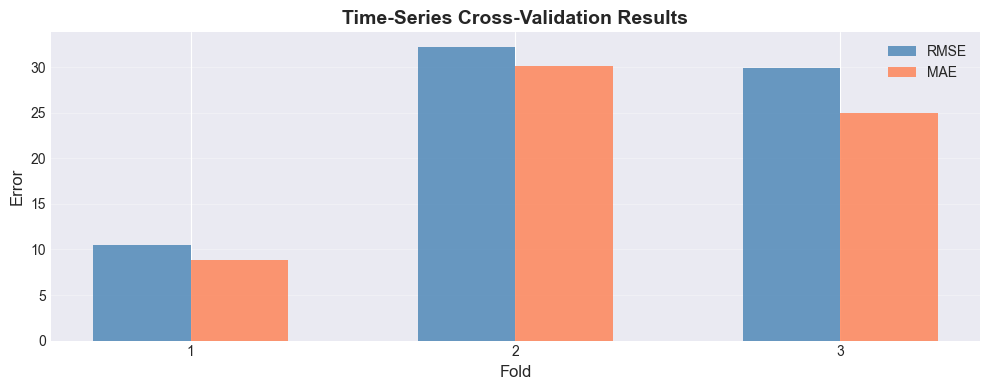

In [17]:
# Rolling window cross-validation for more robust evaluation
from sklearn.model_selection import TimeSeriesSplit

print("Running Time-Series Cross-Validation...\n")

# Use full time series for CV
full_series = ts_daily['adr_mean'].values

# Parameters - adjusted to fit data size
# Formula: n_samples >= test_size * n_splits + min_train_size
n_splits = 3
# Use ~10% of data for each test fold to ensure enough training data
test_size = max(30, len(full_series) // 10)  # At least 30 days per fold

# Verify parameters are valid
min_required = test_size * n_splits
if len(full_series) <= min_required:
    # Reduce splits if needed
    n_splits = max(2, (len(full_series) - 30) // test_size)
    print(f"  Adjusted to {n_splits} splits due to data size constraints")

print(f"  Data size: {len(full_series)} samples")
print(f"  Test size per fold: {test_size} days")
print(f"  Number of folds: {n_splits}\n")

tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(full_series)):
    train_cv = full_series[train_idx]
    val_cv = full_series[val_idx]

    if len(train_cv) < 30:  # Skip if training set too small
        continue

    try:
        # Fit a simple ARIMA(1,1,1) for CV evaluation
        model_cv = ARIMA(train_cv, order=(1, 1, 1))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit_cv = model_cv.fit()

        forecast_cv = fit_cv.forecast(steps=len(val_cv))

        rmse_cv = np.sqrt(mean_squared_error(val_cv, forecast_cv))
        mae_cv = mean_absolute_error(val_cv, forecast_cv)

        cv_results.append({
            'Fold': fold + 1,
            'Train_Size': len(train_cv),
            'Test_Size': len(val_cv),
            'RMSE': rmse_cv,
            'MAE': mae_cv
        })

        print(f"Fold {fold + 1}: Train={len(train_cv)}, Test={len(val_cv)}, RMSE={rmse_cv:.2f}, MAE={mae_cv:.2f}")

    except Exception as e:
        print(f"Fold {fold + 1}: Failed - {str(e)[:40]}")

if cv_results:
    cv_df = pd.DataFrame(cv_results)
    print(f"\n{'='*60}")
    print("CROSS-VALIDATION SUMMARY (ARIMA(1,1,1))")
    print(f"{'='*60}")
    print(f"Mean RMSE: {cv_df['RMSE'].mean():.2f} ± {cv_df['RMSE'].std():.2f}")
    print(f"Mean MAE:  {cv_df['MAE'].mean():.2f} ± {cv_df['MAE'].std():.2f}")
    print(f"{'='*60}")

    # Visualize CV results
    fig, ax = plt.subplots(figsize=(10, 4))
    x = cv_df['Fold']
    ax.bar(x - 0.15, cv_df['RMSE'], width=0.3, label='RMSE', color='steelblue', alpha=0.8)
    ax.bar(x + 0.15, cv_df['MAE'], width=0.3, label='MAE', color='coral', alpha=0.8)
    ax.set_xlabel('Fold', fontsize=12)
    ax.set_ylabel('Error', fontsize=12)
    ax.set_title('Time-Series Cross-Validation Results', fontsize=14, fontweight='bold')
    ax.legend()
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No CV results generated")

## 7. Compare All Models

In [18]:
# Combine all results
all_models = []

# Add baselines
for result in baseline_results:
    all_models.append({
        'Model': result['Model'],
        'Type': 'Baseline',
        'RMSE': result['RMSE'],
        'MAE': result['MAE'],
        'MAPE (%)': result['MAPE (%)'],
    })

# Add ARIMA models
for _, row in arima_df.iterrows():
    all_models.append({
        'Model': f"ARIMA{row['Order']}",
        'Type': 'ARIMA',
        'RMSE': row['RMSE'],
        'MAE': row['MAE'],
        'MAPE (%)': row['MAPE (%)'],
    })

# Add SARIMA models
if len(sarima_df) > 0:
    for _, row in sarima_df.iterrows():
        all_models.append({
            'Model': f"SARIMA{row['Order']}",
            'Type': 'SARIMA',
            'RMSE': row['RMSE'],
            'MAE': row['MAE'],
            'MAPE (%)': row['MAPE (%)'],
        })

# Add auto_arima result if available
if has_auto_arima and auto_arima_result is not None:
    all_models.append({
        'Model': f"Auto-ARIMA{auto_arima_result['Order']}",
        'Type': 'Auto-ARIMA',
        'RMSE': auto_arima_result['RMSE'],
        'MAE': auto_arima_result['MAE'],
        'MAPE (%)': auto_arima_result['MAPE (%)'],
    })

all_models_df = pd.DataFrame(all_models)
all_models_df = all_models_df.sort_values('RMSE').reset_index(drop=True)

print("\n" + "="*75)
print("ALL MODELS COMPARISON (sorted by RMSE)")
print("="*75)
print(all_models_df.to_string(index=False))
print("="*75)


ALL MODELS COMPARISON (sorted by RMSE)
                           Model       Type      RMSE       MAE  MAPE (%)
                            Mean   Baseline 46.300672 41.031746 29.195598
    SARIMA(1, 1, 1)x(1, 0, 1, 7)     SARIMA 47.308314 42.774744 30.660712
    SARIMA(2, 1, 1)x(1, 0, 1, 7)     SARIMA 48.834486 44.310555 31.802553
Auto-ARIMA(3, 1, 2)x(1, 0, 1, 7) Auto-ARIMA 49.783645 45.208946 32.455723
    SARIMA(1, 1, 1)x(1, 1, 1, 7)     SARIMA 49.839576 45.146905 32.394938
    SARIMA(2, 1, 2)x(1, 0, 1, 7)     SARIMA 49.861094 45.318435 32.547517
    SARIMA(1, 1, 2)x(1, 0, 1, 7)     SARIMA 49.975755 45.429857 32.629924
                  ARIMA(5, 1, 0)      ARIMA 50.451943 45.421213 32.486085
                  ARIMA(1, 1, 3)      ARIMA 50.514753 45.486845 32.534681
                  ARIMA(1, 1, 1)      ARIMA 50.602536 45.578426 32.603089
                  ARIMA(7, 1, 0)      ARIMA 51.167039 46.186830 33.067283
         Moving Average (7 days)   Baseline 51.202107 46.214845 33.08438

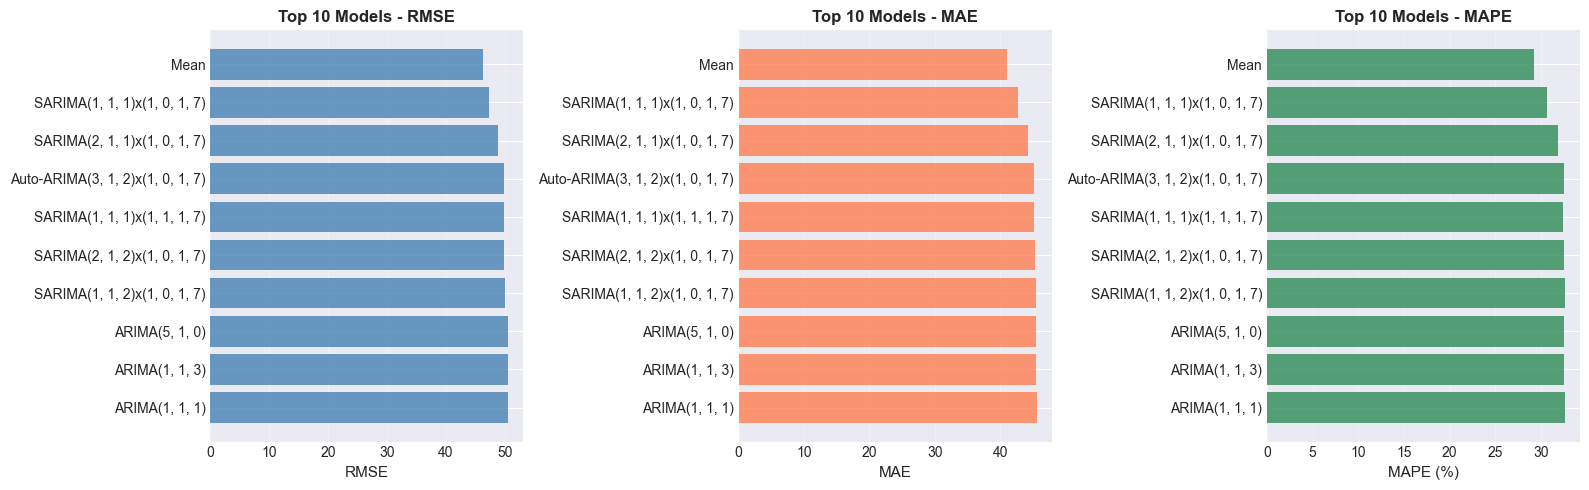

In [19]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE comparison
top_n = min(10, len(all_models_df))
top_models = all_models_df.head(top_n)

axes[0].barh(range(len(top_models)), top_models['RMSE'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_models)))
axes[0].set_yticklabels(top_models['Model'])
axes[0].set_xlabel('RMSE', fontsize=11)
axes[0].set_title(f'Top {top_n} Models - RMSE', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1].barh(range(len(top_models)), top_models['MAE'], color='coral', alpha=0.8)
axes[1].set_yticks(range(len(top_models)))
axes[1].set_yticklabels(top_models['Model'])
axes[1].set_xlabel('MAE', fontsize=11)
axes[1].set_title(f'Top {top_n} Models - MAE', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# MAPE comparison
axes[2].barh(range(len(top_models)), top_models['MAPE (%)'], color='seagreen', alpha=0.8)
axes[2].set_yticks(range(len(top_models)))
axes[2].set_yticklabels(top_models['Model'])
axes[2].set_xlabel('MAPE (%)', fontsize=11)
axes[2].set_title(f'Top {top_n} Models - MAPE', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Best Model Analysis and Visualization

In [20]:
# Identify best model
best_model_name = all_models_df.iloc[0]['Model']
best_model_type = all_models_df.iloc[0]['Type']

print()
print(f"{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Type: {best_model_type}")
print(f"RMSE: {all_models_df.iloc[0]['RMSE']:.2f}")
print(f"MAE: {all_models_df.iloc[0]['MAE']:.2f}")
print(f"MAPE: {all_models_df.iloc[0]['MAPE (%)']:.2f}%")
print(f"{'='*60}")

# Get best forecast
if best_model_type == 'Baseline':
    if 'Naive' in best_model_name:
        best_forecast = naive_forecast
    elif 'Mean' in best_model_name:
        best_forecast = mean_forecast
    elif 'Moving Average' in best_model_name:
        best_forecast = ma_forecast
    else:
        best_forecast = seasonal_naive_forecast
    best_model_obj = None
    best_conf_int = None
elif best_model_type == 'Auto-ARIMA':
    best_forecast = auto_arima_result['Forecast']
    best_model_obj = auto_arima_result['Model']
    best_conf_int = auto_arima_result.get('Conf_Int', None)
elif best_model_type == 'ARIMA':
    best_idx = arima_df['Order'].apply(lambda x: f"ARIMA{x}" == best_model_name).idxmax()
    best_forecast = arima_df.iloc[best_idx]['Forecast']
    best_model_obj = arima_df.iloc[best_idx]['Model']
    # Get confidence intervals for ARIMA
    try:
        forecast_result = best_model_obj.get_forecast(steps=len(test_ts))
        best_conf_int = forecast_result.conf_int().values
    except:
        best_conf_int = None
else:  # SARIMA
    best_idx = sarima_df['Order'].apply(lambda x: f"SARIMA{x}" == best_model_name).idxmax()
    best_forecast = sarima_df.iloc[best_idx]['Forecast']
    best_model_obj = sarima_df.iloc[best_idx]['Model']
    # Get confidence intervals for SARIMA
    try:
        forecast_result = best_model_obj.get_forecast(steps=len(test_ts))
        best_conf_int = forecast_result.conf_int().values
    except:
        best_conf_int = None

best_forecast_valid = align_forecast(best_forecast)



BEST MODEL: Mean
Type: Baseline
RMSE: 46.30
MAE: 41.03
MAPE: 29.20%


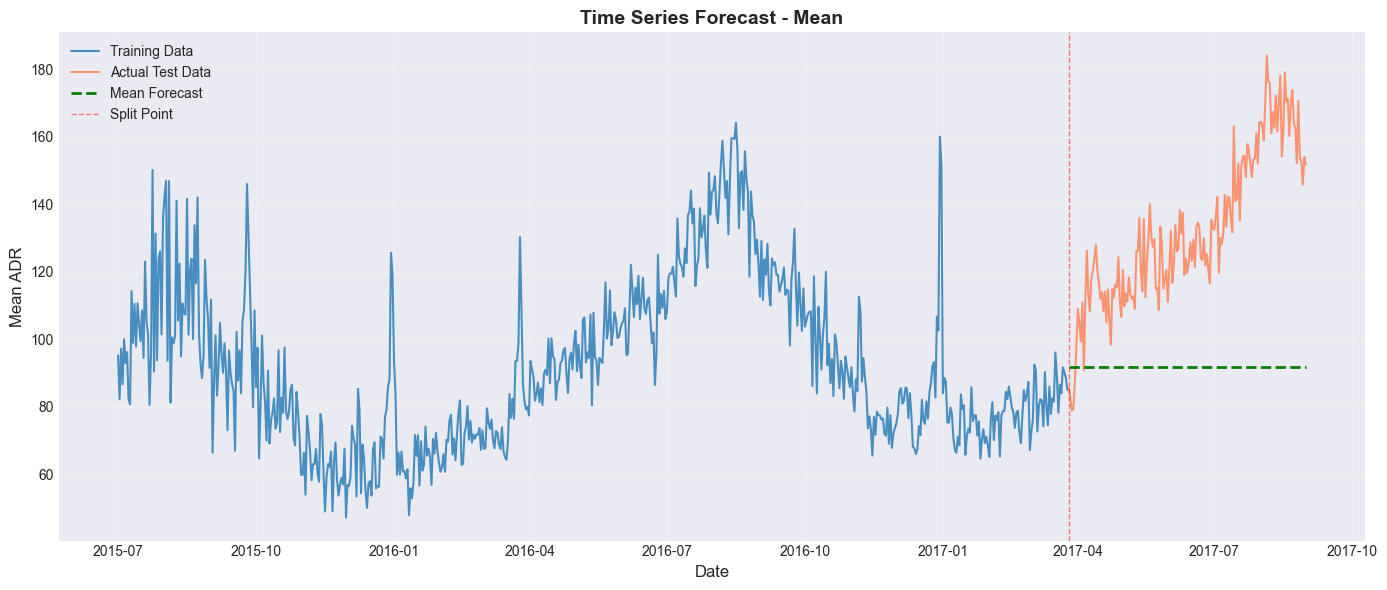

In [21]:
# Visualize best model forecast with confidence intervals
fig, ax = plt.subplots(figsize=(14, 6))

# Plot historical data
ax.plot(train_ts.index, train_ts['adr_mean'], label='Training Data', linewidth=1.5, alpha=0.8)
ax.plot(test_ts_plot.index, test_ts_plot['adr_mean'], label='Actual Test Data', linewidth=1.5, alpha=0.8, color='coral')

# Plot forecast
ax.plot(test_ts.index, best_forecast, label=f'{best_model_name} Forecast',
        linewidth=2, linestyle='--', color='green')

# Plot confidence intervals if available
if best_conf_int is not None:
    ax.fill_between(test_ts.index,
                    best_conf_int[:, 0],
                    best_conf_int[:, 1],
                    alpha=0.2, color='green',
                    label='95% Confidence Interval')
    print(f"? Confidence intervals added to forecast visualization")

ax.axvline(x=split_date, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Split Point')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean ADR', fontsize=12)
ax.set_title(f'Time Series Forecast - {best_model_name}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


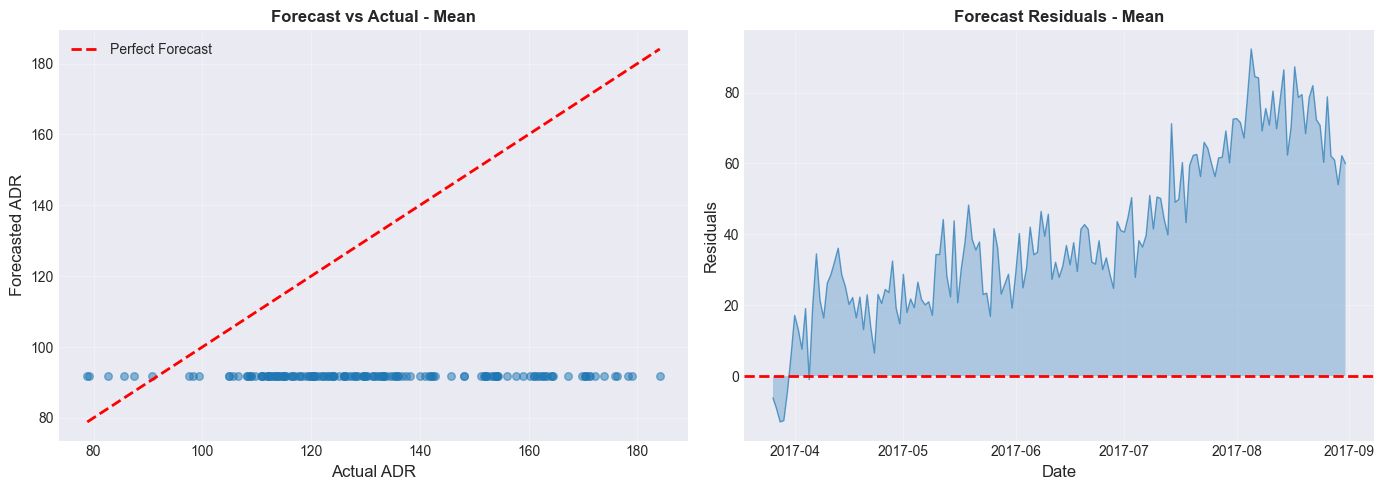

In [22]:
# Forecast vs Actual scatter and residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_true, best_forecast_valid, alpha=0.5, s=30)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
             'r--', linewidth=2, label='Perfect Forecast')
axes[0].set_xlabel('Actual ADR', fontsize=12)
axes[0].set_ylabel('Forecasted ADR', fontsize=12)
axes[0].set_title(f'Forecast vs Actual - {best_model_name}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_true - best_forecast_valid
axes[1].plot(valid_idx, residuals, linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].fill_between(valid_idx, 0, residuals, alpha=0.3)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'Forecast Residuals - {best_model_name}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


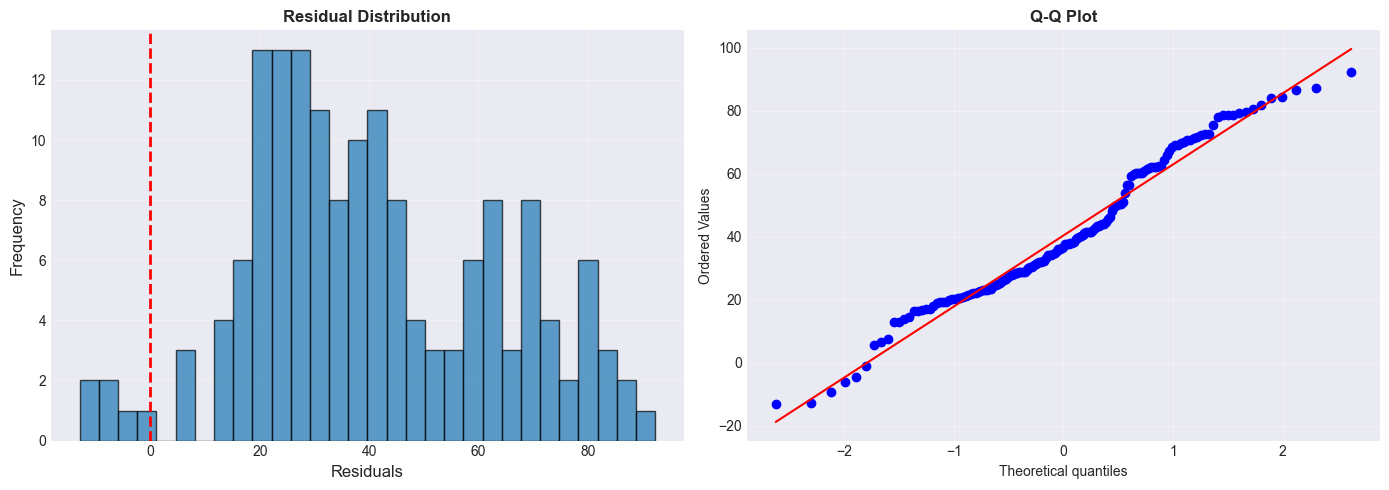

In [23]:
# Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Diagnostics (for ARIMA/SARIMA)

In [24]:
# Show model summary if ARIMA/SARIMA
if best_model_obj is not None:
    print("\nModel Summary:")
    print(best_model_obj.summary())
else:
    print(f"\nBest model is a baseline method ({best_model_name}), no statistical summary available.")


Best model is a baseline method (Mean), no statistical summary available.


In [25]:
# Plot diagnostics if ARIMA/SARIMA
if best_model_obj is not None:
    best_model_obj.plot_diagnostics(figsize=(14, 8))
    plt.tight_layout()
    plt.show()

## 10. Save Models and Results

In [26]:
# Create artifacts directory
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save best model
if best_model_obj is not None:
    model_path = artifacts_dir / 'adr_timeseries_model.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(best_model_obj, f)
    print(f"✓ Best model saved to: {model_path}")
else:
    print(f"✓ Best model is baseline ({best_model_name}), no model object to save")

# Save time series data
ts_data_path = artifacts_dir / 'adr_timeseries_data.pkl'
with open(ts_data_path, 'wb') as f:
    pickle.dump({
        'train': train_ts,
        'test': test_ts,
        'split_date': split_date
    }, f)
print(f"✓ Time series data saved to: {ts_data_path}")

# Save metadata
metadata = {
    'best_model_name': best_model_name,
    'best_model_type': best_model_type,
    'rmse': all_models_df.iloc[0]['RMSE'],
    'mae': all_models_df.iloc[0]['MAE'],
    'mape': all_models_df.iloc[0]['MAPE (%)'],
    'split_date': str(split_date),
    'train_size': len(train_ts),
    'test_size': len(test_ts),
    'forecast_horizon': len(test_ts)
}

metadata_path = artifacts_dir / 'adr_timeseries_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Model metadata saved to: {metadata_path}")

✓ Best model is baseline (Mean), no model object to save
✓ Time series data saved to: ..\artifacts\adr_timeseries_data.pkl
✓ Model metadata saved to: ..\artifacts\adr_timeseries_metadata.pkl


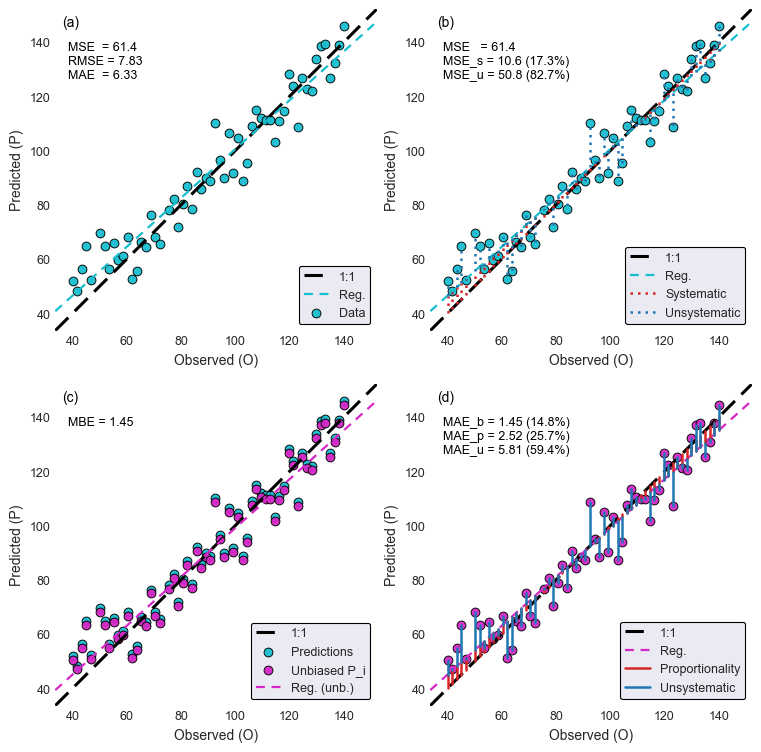

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def make_decomposition_plot(obs, pred):
    """
    2x2 decomposition figure (a–d) styled to match a reference look.
    Inputs: 1D arrays obs, pred (same length). NaNs dropped pairwise.
    Returns: (fig, ax)
    """
    # ---- clean data (pairwise drop NaNs) ----
    obs = np.asarray(obs, dtype=float).ravel()
    pred = np.asarray(pred, dtype=float).ravel()
    m = np.isfinite(obs) & np.isfinite(pred)
    O = obs[m]
    P = pred[m]
    if O.size < 2:
        raise ValueError("Need at least 2 finite (obs, pred) pairs after dropping NaNs.")

    # ---- helpers ----
    def _linreg(x, y):
        # y = a + b*x
        xm = x.mean()
        ym = y.mean()
        sxx = np.sum((x - xm) ** 2)
        if sxx == 0:
            b = 0.0
        else:
            b = np.sum((x - xm) * (y - ym)) / sxx
        a = ym - b * xm
        return a, b

    def _metrics(o, p):
        e = p - o
        mse = np.mean(e ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(e))
        mbe = np.mean(e)
        return mse, rmse, mae, mbe

    # ---- colors / style ----
    c_pred = "#17becf"     # cyan
    c_reg  = "#17becf"     # cyan regression (a,b)
    c_unb  = "#d627c8"     # magenta-ish
    c_sys  = "#d62728"     # red
    c_uns  = "#1f77b4"     # blue

    fs_lbl = 10
    fs_txt = 9
    lw_11  = 2.2
    lw_reg = 1.6
    lw_seg = 1.8

    # ---- axis limits (shared) ----
    xy = np.concatenate([O, P])
    lo = np.nanmin(xy)
    hi = np.nanmax(xy)
    pad = 0.06 * (hi - lo if hi > lo else 1.0)
    xlim = (lo - pad, hi + pad)
    ylim = (lo - pad, hi + pad)

    # ---- canonical regression P on O ----
    a, b = _linreg(O, P)
    Phat = a + b * O

    # ---- metrics (panel a text) ----
    mse, rmse, mae, mbe = _metrics(O, P)

    # ---- MSE decomposition (panel b) ----
    # systematic = (Phat - O), unsystematic = (P - Phat)
    mse_s = np.mean((Phat - O) ** 2)
    mse_u = np.mean((P - Phat) ** 2)
    pct_s = 100.0 * mse_s / mse if mse > 0 else 0.0
    pct_u = 100.0 * mse_u / mse if mse > 0 else 0.0

    # ---- unbiased series (panel c/d) ----
    MBE = mbe
    Pu = P - MBE  # remove bias
    a_u, b_u = _linreg(O, Pu)
    Puhat = a_u + b_u * O

    # ---- MAE decomposition visuals (panel d text with absolute contributions) ----
    # proportionality (around Pu_hat vs O) + unsystematic (Pu vs Pu_hat) + bias (MBE)
    mae_b = np.abs(MBE)
    mae_p = np.mean(np.abs(Puhat - O))
    mae_u = np.mean(np.abs(Pu - Puhat))
    mae_tot = mae_b + mae_p + mae_u
    pct_b = 100.0 * mae_b / mae_tot if mae_tot > 0 else 0.0
    pct_p = 100.0 * mae_p / mae_tot if mae_tot > 0 else 0.0
    pct_uu = 100.0 * mae_u / mae_tot if mae_tot > 0 else 0.0

    # ---- figure ----
    fig, ax = plt.subplots(2, 2, figsize=(7.5, 7.5), constrained_layout=True)
    ax = ax.ravel()

    # shared formatting
    for i, axy in enumerate(ax):
        axy.set_facecolor("white")
        axy.set_xlim(xlim)
        axy.set_ylim(ylim)
        axy.set_xlabel("Observed (O)", fontsize=fs_lbl)
        axy.set_ylabel("Predicted (P)", fontsize=fs_lbl)
        axy.tick_params(labelsize=fs_txt)
        axy.set_aspect("equal", adjustable="box")
        # panel label
        axy.text(0.02, 0.98, f"({chr(97+i)})", transform=axy.transAxes,
                 ha="left", va="top", color="black", fontsize=fs_lbl)

    # 1:1 line coords
    xx = np.array([xlim[0], xlim[1]])

    # --- Panel (a): scatter + 1:1 + regression + metrics text ---
    ax[0].plot(xx, xx, "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    ax[0].plot(xx, a + b * xx, color=c_reg, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg.")
    ax[0].scatter(O, P, s=40, marker="o", facecolor=c_pred, edgecolor="black", linewidth=0.7,
                  alpha=0.95, label="Data")
    ax[0].text(0.04, 0.90,
               f"MSE  = {mse:.3g}\nRMSE = {rmse:.3g}\nMAE  = {mae:.3g}",
               transform=ax[0].transAxes, ha="left", va="top", fontsize=fs_txt, color="black")
    leg0 = ax[0].legend(loc="lower right", fontsize=fs_txt, frameon=True, framealpha=1.0)
    leg0.get_frame().set_edgecolor("black")
    leg0.get_frame().set_linewidth(0.8)

    # --- Panel (b): same + vertical dotted decomposition segments ---
    ax[1].plot(xx, xx, "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    ax[1].plot(xx, a + b * xx, color=c_reg, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg.")
    ax[1].scatter(O, P, s=40, marker="o", facecolor=c_pred, edgecolor="black", linewidth=0.7,
                  alpha=0.95, label="Data")

    # segments (draw behind markers)
    for oi, pi, phti in zip(O, P, Phat):
        # systematic: from y=O to y=Phat at x=O
        ax[1].plot([oi, oi], [oi, phti], color=c_sys, lw=lw_seg, ls=":", dashes=(1, 2))
        # unsystematic: from y=Phat to y=P at x=O
        ax[1].plot([oi, oi], [phti, pi], color=c_uns, lw=lw_seg, ls=":", dashes=(1, 2))

    ax[1].text(0.04, 0.90,
               f"MSE   = {mse:.3g}\n"
               f"MSE_s = {mse_s:.3g} ({pct_s:.1f}%)\n"
               f"MSE_u = {mse_u:.3g} ({pct_u:.1f}%)",
               transform=ax[1].transAxes, ha="left", va="top", fontsize=fs_txt, color="black")

    # legend with systematic/unsystematic styles (plus 1:1/reg if desired)
    h_sys, = ax[1].plot([], [], color=c_sys, lw=lw_seg, ls=":", dashes=(1, 2), label="Systematic")
    h_uns, = ax[1].plot([], [], color=c_uns, lw=lw_seg, ls=":", dashes=(1, 2), label="Unsystematic")
    h_11,  = ax[1].plot([], [], "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    h_rg,  = ax[1].plot([], [], color=c_reg, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg.")
    leg1 = ax[1].legend(handles=[h_11, h_rg, h_sys, h_uns], loc="lower right",
                        fontsize=fs_txt, frameon=True, framealpha=1.0)
    leg1.get_frame().set_edgecolor("black")
    leg1.get_frame().set_linewidth(0.8)

    # --- Panel (c): show unbiased predictions ---
    ax[2].plot(xx, xx, "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    ax[2].scatter(O, P, s=40, marker="o", facecolor=c_pred, edgecolor="black", linewidth=0.7,
                  alpha=0.95, label="Predictions")
    ax[2].scatter(O, Pu, s=40, marker="o", facecolor=c_unb, edgecolor="black", linewidth=0.7,
                  alpha=0.95, label="Unbiased P_i")
    ax[2].plot(xx, a_u + b_u * xx, color=c_unb, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg. (unb.)")
    ax[2].text(0.04, 0.90, f"MBE = {MBE:.3g}", transform=ax[2].transAxes,
               ha="left", va="top", fontsize=fs_txt, color="black")
    leg2 = ax[2].legend(loc="lower right", fontsize=fs_txt, frameon=True, framealpha=1.0)
    leg2.get_frame().set_edgecolor("black")
    leg2.get_frame().set_linewidth(0.8)

    # --- Panel (d): MAE decomposition visuals with solid segments + magenta regression ---
    ax[3].plot(xx, xx, "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    ax[3].plot(xx, a_u + b_u * xx, color=c_unb, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg.")
    ax[3].scatter(O, Pu, s=40, marker="o", facecolor=c_unb, edgecolor="black", linewidth=0.7,
                  alpha=0.95, label="Unbiased P_i")

    for oi, pui, puhati in zip(O, Pu, Puhat):
        # proportionality: O -> Pu_hat
        ax[3].plot([oi, oi], [oi, puhati], color=c_sys, lw=lw_seg, ls="-")
        # unsystematic: Pu_hat -> Pu
        ax[3].plot([oi, oi], [puhati, pui], color=c_uns, lw=lw_seg, ls="-")

    ax[3].text(0.04, 0.90,
               f"MAE_b = {mae_b:.3g} ({pct_b:.1f}%)\n"
               f"MAE_p = {mae_p:.3g} ({pct_p:.1f}%)\n"
               f"MAE_u = {mae_u:.3g} ({pct_uu:.1f}%)",
               transform=ax[3].transAxes, ha="left", va="top", fontsize=fs_txt, color="black")

    h_prop, = ax[3].plot([], [], color=c_sys, lw=lw_seg, ls="-", label="Proportionality")
    h_uns2, = ax[3].plot([], [], color=c_uns, lw=lw_seg, ls="-", label="Unsystematic")
    h_11d,  = ax[3].plot([], [], "k--", lw=lw_11, dashes=(6, 3), label="1:1")
    h_rgd,  = ax[3].plot([], [], color=c_unb, lw=lw_reg, ls="--", dashes=(4, 3), label="Reg.")
    leg3 = ax[3].legend(handles=[h_11d, h_rgd, h_prop, h_uns2], loc="lower right",
                        fontsize=fs_txt, frameon=True, framealpha=1.0)
    leg3.get_frame().set_edgecolor("black")
    leg3.get_frame().set_linewidth(0.8)

    return fig, ax

# ---- example call (runnable) ----
np.random.seed(42)
obs = np.linspace(40, 140, 60)
pred = 0.9 * obs + 12 + np.random.normal(0, 8, size=obs.size)
pred[[5, 20]] = np.nan  # example NaNs

fig, ax = make_decomposition_plot(obs, pred)
plt.show()

## Summary

**Time-series ADR forecasting completed successfully:**

1. ✓ Aggregated ADR data by date for daily time series
2. ✓ Used time-based train/test split (80/20)
3. ✓ Built 4 baseline forecasts: Naive, Mean, Moving Average, Seasonal Naive
4. ✓ Analyzed stationarity using ADF test and ACF/PACF plots
5. ✓ Tested multiple ARIMA configurations with different (p,d,q) orders
6. ✓ Tested SARIMA models with weekly seasonality (period=7)
7. ✓ Compared all models using RMSE, MAE, and MAPE
8. ✓ Visualized forecasts, residuals, and diagnostics
9. ✓ Saved best model and results to `artifacts/` and `reports/`

**Key Findings:**
- Time series shows daily fluctuations with weekly patterns
- ARIMA/SARIMA models compared against simple baselines
- Best model performance documented with diagnostic plots

**Next steps:**
- Notebook 04: DiCE counterfactual explanations for the classification model

